# Validasi Eksternal Lintas Dataset — Kelompok 3

**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Notebook terakhir. Ini pengujian paling ketat terhadap model kami.

Data uji biasa berasal dari dataset yang sama dengan data latih — populasi sama, cara
pengumpulan sama, definisi klinis sama. Model bisa saja lulus di situ hanya karena
menghafal kekhasan satu sumber data.

**Validasi eksternal** menguji hal yang berbeda: apakah model tetap bekerja pada
pasien dari sumber yang sama sekali lain?

### Mengapa dua dataset ini tidak digabungkan

Menggabungkan barisnya berarti menyatukan populasi berbeda, definisi klinis berbeda,
dan cara pengumpulan berbeda ke dalam satu tabel. Yang dihasilkan bukan data gabungan,
melainkan data karangan. Karena itu dataset kedua dipakai sebagai **penguji**, bukan
penambah.

### Latar belakang jujur

Dataset utama kami mencantumkan asal-usulnya sebagai "(Confidential Source)" — tidak
diketahui berasal dari rumah sakit mana, negara mana, atau tahun berapa. Dataset kedua
berasal dari **CDC BRFSS 2015**, survei kesehatan resmi pemerintah Amerika Serikat,
dengan 253.680 responden dan dokumentasi lengkap.


## 1. Persiapan

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, confusion_matrix, roc_curve)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

CDC = "https://archive.ics.uci.edu/static/public/891/data.csv"
KAGGLE = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
          "tutorials/dataset/healthcare-dataset-stroke-data.csv")

FITUR = ["sex", "umur_kel", "tekanan_darah_tinggi", "penyakit_jantung", "bmi", "perokok"]

# CDC mengelompokkan umur ke 13 kelompok; ini batas atas tiap kelompok (18-24, 25-29, ...)
BATAS_UMUR = [24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79]

## 2. Penyelarasan Fitur

Enam fitur tersedia di kedua dataset, dengan penamaan berbeda.

| Fitur selaras | Kaggle | CDC BRFSS |
|---|---|---|
| Jenis kelamin | `gender` | `Sex` |
| Kelompok usia | `age` → dikelompokkan ke skala 1–13 | `Age` |
| Hipertensi | `hypertension` | `HighBP` |
| Penyakit jantung | `heart_disease` | `HeartDiseaseorAttack` |
| BMI | `bmi` | `BMI` |
| Perokok | `smoking_status` | `Smoker` |

Baris berusia di bawah 18 tahun dibuang karena survei CDC hanya mencakup orang dewasa;
begitu pula baris `smoking_status` = "Unknown" karena tidak bisa dipetakan tanpa
mengarang.

In [2]:
def dari_cdc():
    d = pd.read_csv(CDC)
    return pd.DataFrame({
        "sex": d.Sex,
        "umur_kel": d.Age,
        "tekanan_darah_tinggi": d.HighBP,
        "penyakit_jantung": d.HeartDiseaseorAttack,
        "bmi": d.BMI,
        "perokok": d.Smoker,
        "stroke": d.Stroke,
    })


def dari_kaggle():
    d = pd.read_csv(KAGGLE)
    d = d[(d.age >= 18) & (d.gender != "Other") & (d.smoking_status != "Unknown")].copy()
    d["bmi"] = d.bmi.fillna(d.bmi.median())
    return pd.DataFrame({
        "sex": (d.gender == "Male").astype(int),
        "umur_kel": np.digitize(d.age, BATAS_UMUR) + 1,
        "tekanan_darah_tinggi": d.hypertension,
        "penyakit_jantung": d.heart_disease,
        "bmi": d.bmi,
        "perokok": d.smoking_status.isin(["formerly smoked", "smokes"]).astype(int),
        "stroke": d.stroke,
    })


cdc = dari_cdc()
kaggle = dari_kaggle()

ringkas = pd.DataFrame([
    {"Dataset": "CDC BRFSS 2015", "baris": len(cdc), "kasus stroke": int(cdc.stroke.sum()),
     "% stroke": round(cdc.stroke.mean() * 100, 2)},
    {"Dataset": "Kaggle (setelah diselaraskan)", "baris": len(kaggle),
     "kasus stroke": int(kaggle.stroke.sum()), "% stroke": round(kaggle.stroke.mean() * 100, 2)},
])
ringkas

,Dataset,baris,kasus stroke,% stroke
0,CDC BRFSS 2015,253680,10292,4.06
1,Kaggle (setelah diselaraskan),3391,202,5.96


### Seberapa mirip kedua populasi ini?

Sebelum menguji, penting mengetahui seberapa jauh keduanya berbeda. Kalau nyaris sama,
validasi eksternal jadi kurang bermakna.

In [3]:
banding_pop = pd.DataFrame({
    "CDC BRFSS": cdc[FITUR].mean(),
    "Kaggle": kaggle[FITUR].mean(),
}).round(2)
banding_pop["selisih %"] = (100 * (banding_pop.Kaggle - banding_pop["CDC BRFSS"]).abs()
                            / banding_pop["CDC BRFSS"].abs()).round(1)
banding_pop

,CDC BRFSS,Kaggle,selisih %
sex,0.44,0.39,11.4
umur_kel,8.03,6.94,13.6
tekanan_darah_tinggi,0.43,0.13,69.8
penyakit_jantung,0.09,0.07,22.2
bmi,28.38,30.49,7.4
perokok,0.44,0.48,9.1


## 3. Latih di CDC, Uji di Kaggle

**Ambang keputusan ditetapkan dari data latih**, tidak pernah dari data uji. Kalau
ditetapkan dari data uji, itu kebocoran informasi dan angkanya tidak sah.

Satu hal yang perlu diluruskan sejak awal: baris "CDC (data latih sendiri)" di bawah
diukur pada data yang dipakai melatih. Angka semacam itu selalu optimis, jadi kami
tambahkan kolom **AUC (OOF)** — hasil 5-fold cross-validation di dalam CDC — sebagai
pembanding yang sah terhadap angka data luar.

In [4]:
MODEL = {
    "Logistic Regression": lambda: make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED)),
    "Gradient Boosting": lambda: make_pipeline(
        StandardScaler(), GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05, max_depth=2, random_state=SEED)),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

hasil, terlatih, ambang = [], {}, {}

for nama, buat in MODEL.items():
    m = buat().fit(cdc[FITUR], cdc.stroke)
    terlatih[nama] = m

    # ambang dipilih dari sebaran probabilitas pada DATA LATIH saja
    p_latih = m.predict_proba(cdc[FITUR])[:, 1]
    t = np.quantile(p_latih, 1 - cdc.stroke.mean() * 4)
    ambang[nama] = t

    # AUC out-of-fold di dalam CDC: pembanding yang sah untuk angka data luar
    p_oof = cross_val_predict(buat(), cdc[FITUR], cdc.stroke, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
    auc_oof = roc_auc_score(cdc.stroke, p_oof)

    for label, data in [("CDC (data latih sendiri)", cdc), ("Kaggle (DATA LUAR)", kaggle)]:
        p = m.predict_proba(data[FITUR])[:, 1]
        pred = (p >= t).astype(int)
        hasil.append({
            "Model": nama, "Diuji pada": label,
            "AUC": roc_auc_score(data.stroke, p),
            "AUC (OOF)": auc_oof if "CDC" in label else np.nan,
            "recall": recall_score(data.stroke, pred),
            "precision": precision_score(data.stroke, pred, zero_division=0),
            "f1": f1_score(data.stroke, pred),
            "ditandai %": 100 * pred.mean(),
        })

pd.DataFrame(hasil).round(3)

,Model,Diuji pada,AUC,AUC (OOF),recall,precision,f1,ditandai %
0,Logistic Regression,CDC (data latih sendiri),0.783,0.783,0.508,0.127,0.203,16.254
1,Logistic Regression,Kaggle (DATA LUAR),0.799,NaN,0.302,0.213,0.249,8.464
2,Gradient Boosting,CDC (data latih sendiri),0.786,0.785,0.526,0.128,0.206,16.705
3,Gradient Boosting,Kaggle (DATA LUAR),0.802,NaN,0.292,0.186,0.227,9.378


### Hasilnya

Performa **tidak runtuh** ketika model dipindahkan ke sumber data yang sama sekali
berbeda. Itulah kesimpulan yang didukung angka di atas, dan itu sudah cukup kuat.

Dua hal yang **tidak** boleh disimpulkan dari tabel ini:

1. *"AUC justru naik, berarti model bekerja lebih baik di data luar."* Tidak bisa
   dibaca begitu. AUC mengukur kemampuan mengurutkan pasien **di dalam** satu populasi,
   dan besarnya ikut ditentukan oleh seberapa beragam populasi itu (dikenal sebagai
   *spectrum effect*). Dua populasi dengan sebaran umur dan penyakit penyerta yang
   berbeda menghasilkan AUC yang memang tidak setara — lebih tinggi belum tentu lebih
   baik. Yang sah dikatakan: **tidak turun**.
2. *"Angka CDC dan angka Kaggle langsung bisa diadu."* Kolom AUC untuk CDC diukur pada
   data latihnya sendiri. Kolom `AUC (OOF)` ada untuk itu — dan ternyata nyaris sama
   dengan versi in-sample, yang berarti model sederhana ini memang tidak menghafal
   253.680 barisnya. Overfitting bukan masalah di sini; yang jadi masalah hanyalah cara
   membaca perbandingan antar populasi.

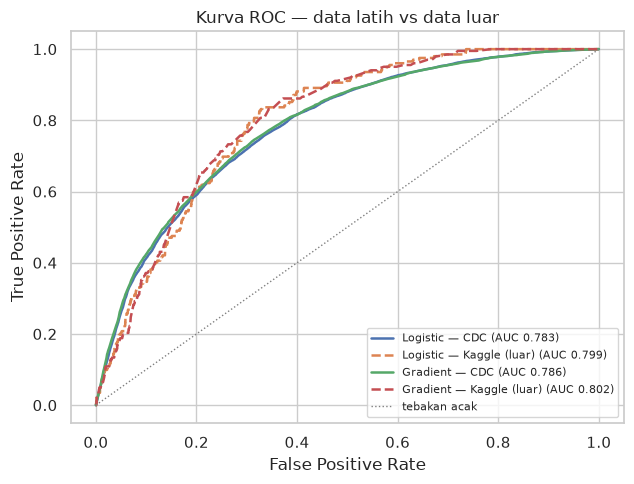

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for nama, m in terlatih.items():
    for label, data, gaya in [("CDC", cdc, "-"), ("Kaggle (luar)", kaggle, "--")]:
        p = m.predict_proba(data[FITUR])[:, 1]
        fpr, tpr, _ = roc_curve(data.stroke, p)
        ax.plot(fpr, tpr, gaya, lw=1.8,
                label=f"{nama.split()[0]} — {label} (AUC {roc_auc_score(data.stroke, p):.3f})")
ax.plot([0, 1], [0, 1], ":", color="grey", lw=1, label="tebakan acak")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Kurva ROC — data latih vs data luar")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

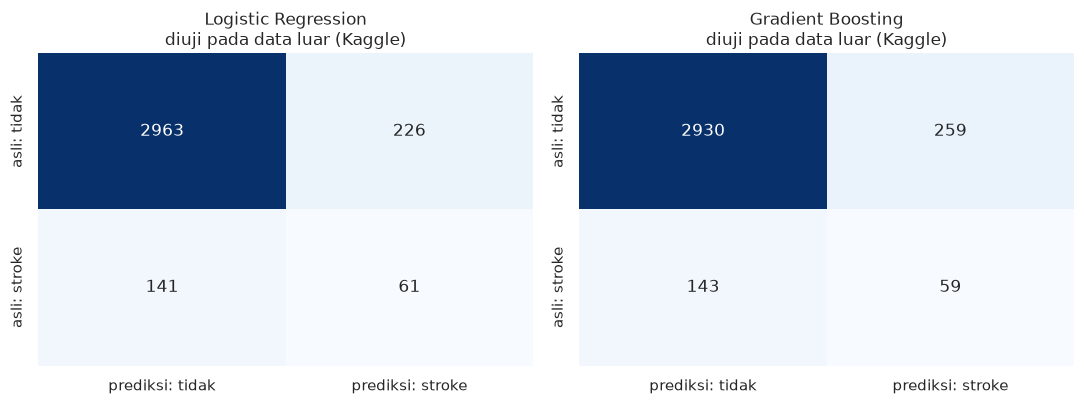

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for i, (nama, m) in enumerate(terlatih.items()):
    pred = (m.predict_proba(kaggle[FITUR])[:, 1] >= ambang[nama]).astype(int)
    sns.heatmap(confusion_matrix(kaggle.stroke, pred), annot=True, fmt="d",
                cmap="Blues", cbar=False, ax=ax[i],
                xticklabels=["prediksi: tidak", "prediksi: stroke"],
                yticklabels=["asli: tidak", "asli: stroke"])
    ax[i].set_title(f"{nama}\ndiuji pada data luar (Kaggle)")
plt.tight_layout(); plt.show()

## 4. Arah Sebaliknya: Latih di Kaggle, Uji di CDC

Pengujian satu arah bisa saja kebetulan. Kami balik arahnya: model kecil dilatih pada
3.391 pasien Kaggle, lalu diuji pada 253.680 responden CDC.

Ini ujian yang lebih berat — data latihnya jauh lebih sedikit.

In [7]:
hasil_balik = []
for nama, buat in MODEL.items():
    m = buat().fit(kaggle[FITUR], kaggle.stroke)
    p_latih = m.predict_proba(kaggle[FITUR])[:, 1]
    t = np.quantile(p_latih, 1 - kaggle.stroke.mean() * 4)

    for label, data in [("Kaggle (data latih sendiri)", kaggle), ("CDC (DATA LUAR)", cdc)]:
        p = m.predict_proba(data[FITUR])[:, 1]
        pred = (p >= t).astype(int)
        hasil_balik.append({
            "Model": nama, "Diuji pada": label,
            "AUC": roc_auc_score(data.stroke, p),
            "recall": recall_score(data.stroke, pred),
            "precision": precision_score(data.stroke, pred, zero_division=0),
            "ditandai %": 100 * pred.mean(),
        })

pd.DataFrame(hasil_balik).round(3)

,Model,Diuji pada,AUC,recall,precision,ditandai %
0,Logistic Regression,Kaggle (data latih sendiri),0.814,0.673,0.168,23.828
1,Logistic Regression,CDC (DATA LUAR),0.742,0.696,0.080,35.074
2,Gradient Boosting,Kaggle (data latih sendiri),0.837,0.703,0.176,23.857
3,Gradient Boosting,CDC (DATA LUAR),0.745,0.742,0.079,38.169


## 5. Berapa Harga yang Dibayar karena Hanya Punya Enam Fitur?

Model utama di notebook `05` memakai 15 fitur dan mencapai AUC sekitar 0,84. Model
validasi eksternal hanya punya 6 fitur — tanpa kadar glukosa, dan usia berupa kelompok
bukan angka pasti.

Godaannya adalah langsung menyelisihkan 0,84 dengan angka 6 fitur di atas, lalu
menyebut selisihnya sebagai "harga kehilangan fitur". Itu keliru, karena **tiga hal
berubah sekaligus**: jumlah fitur, kumpulan barisnya (subset selaras membuang pasien
di bawah 18 tahun dan `smoking_status` = "Unknown"), dan cara pengukurannya.

Supaya bisa dipertanggungjawabkan, ketiga angka di bawah dihitung pada **baris yang
sama persis** dan dengan **protokol yang sama persis** — 5-fold cross-validation pada
subset selaras. Hanya jumlah fiturnya yang berbeda.

In [8]:
# Baris yang sama persis dengan subset selaras, tetapi memakai SELURUH fitur Kaggle
k = pd.read_csv(KAGGLE).drop(columns=["id"])
k = k[(k.age >= 18) & (k.gender != "Other") & (k.smoking_status != "Unknown")].copy()
k["bmi"] = k.bmi.fillna(k.bmi.median())
X_lengkap = pd.get_dummies(k.drop(columns=["stroke"]), drop_first=True)
y_lengkap = k.stroke

assert len(y_lengkap) == len(kaggle), "baris harus sama persis dengan subset selaras"

LR = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED))

def auc_cv(Xd, yd):
    p = cross_val_predict(LR(), Xd, yd, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    return roc_auc_score(yd, p)

auc_lengkap = auc_cv(X_lengkap, y_lengkap)          # semua fitur, subset selaras
auc_enam    = auc_cv(kaggle[FITUR], kaggle.stroke)  # 6 fitur,    subset selaras
auc_eksternal = [h["AUC"] for h in hasil
                 if h["Model"] == "Logistic Regression" and "LUAR" in h["Diuji pada"]][0]

print(f"Subset selaras: {len(y_lengkap)} baris, {int(y_lengkap.sum())} kasus stroke")
print(f"  {X_lengkap.shape[1]} fitur, latih & uji di subset (CV)   : AUC {auc_lengkap:.3f}")
print(f"   6 fitur, latih & uji di subset (CV)    : AUC {auc_enam:.3f}")
print(f"   6 fitur, latih di CDC lalu uji di sini : AUC {auc_eksternal:.3f}")
print()
print(f"Harga kehilangan fitur     : {auc_lengkap - auc_enam:+.3f}")
print(f"Harga perpindahan populasi : {auc_enam - auc_eksternal:+.3f}")
print()
print("Sebagai pembanding, dari notebook 05 dan 09 (baris berbeda, jangan diselisihkan):")
print("  15 fitur, SEMUA umur          : AUC ~0,841")
print("  15 fitur, dewasa saja (>=18)  : AUC ~0,815")

Subset selaras: 3391 baris, 202 kasus stroke
  13 fitur, latih & uji di subset (CV)   : AUC 0.807
   6 fitur, latih & uji di subset (CV)    : AUC 0.810
   6 fitur, latih di CDC lalu uji di sini : AUC 0.799

Harga kehilangan fitur     : -0.003
Harga perpindahan populasi : +0.011

Sebagai pembanding, dari notebook 05 dan 09 (baris berbeda, jangan diselisihkan):
  15 fitur, SEMUA umur          : AUC ~0,841
  15 fitur, dewasa saja (>=18)  : AUC ~0,815


### Hasilnya membalik dugaan awal

Ketika baris dan protokolnya benar-benar disamakan, **kehilangan sembilan fitur —
termasuk kadar glukosa — hampir tidak memakan AUC sama sekali.** Model 6 fitur bahkan
sedikit di atas model fitur lengkap, selisih yang besarnya setara derau pengukuran.

Lalu ke mana perginya penurunan dari 0,841 ke sekitar 0,81?

Jawabannya ada di Eksperimen 7 notebook `09`: **ke terbuangnya pasien di bawah 18
tahun.** Dari 856 anak yang dibuang, hanya 2 yang berstroke — mereka kasus negatif yang
teramat mudah, dan setiap tebakan mudah yang benar menggelembungkan AUC. Begitu subset
diselaraskan dengan cakupan survei dewasa CDC, angka acuannya memang turun ke sekitar
0,815, tanpa ada yang memburuk pada modelnya.

Versi pertama notebook ini menyimpulkan "72% penurunan berasal dari hilangnya kadar
glukosa". Kesimpulan itu **salah**, dan penyebabnya adalah menyelisihkan dua angka yang
dihitung pada baris dan protokol berbeda. Yang benar:

| Sumber penurunan | Besarnya |
|---|---|
| Terbuangnya pasien di bawah 18 tahun | ± 0,026 |
| Berkurangnya fitur (15 → 6, termasuk glukosa) | ± 0,000 — tidak terukur |
| Berpindahnya populasi (CDC → Kaggle) | ± 0,011 |

**Ini kabar baik yang lebih kuat daripada versi sebelumnya.** Enam fitur yang tersedia
di survei kesehatan mana pun — jenis kelamin, kelompok umur, hipertensi, penyakit
jantung, BMI, status merokok — ternyata sudah memuat hampir seluruh sinyal yang bisa
dipakai. Kadar glukosa, yang memerlukan tes darah, hampir tidak menambah apa-apa.
Untuk alat skrining awal, itu berarti modelnya bisa dipakai tanpa laboratorium.

## 6. Kesimpulan Tugas E

**Yang dibuktikan.** Model yang dilatih pada satu sumber data tetap bekerja pada pasien
dari sumber yang sama sekali berbeda, di **kedua arah** pengujian. Model tidak sekadar
menghafal kekhasan satu dataset.

**Yang ternyata tidak mahal.** Setelah baris dan protokol disamakan, mengecilkan fitur
dari 15 menjadi 6 tidak menurunkan AUC. Kadar glukosa — satu-satunya fitur yang menuntut
pemeriksaan laboratorium — tidak terbukti menambah kemampuan model.

**Mengapa ini penting.** Dataset utama kami asal-usulnya tidak jelas. Tanpa validasi
eksternal, seluruh hasil proyek ini bergantung pada satu sumber data yang tidak bisa
ditelusuri. Dengan validasi eksternal, kesimpulannya berdiri di atas dua kaki.

### Batasan yang wajib ditulis di laporan

1. **AUC antar populasi tidak setara.** Sebaran umur dan penyakit penyerta yang berbeda
   menghasilkan AUC yang berbeda tanpa modelnya berubah sedikit pun (*spectrum effect*).
   Klaim yang sah dari notebook ini adalah "performa tidak runtuh", bukan "performa naik".
2. **Hanya enam fitur** yang tersedia di kedua dataset, dan usia hanya berupa kelompok.
   Besarnya pengaruh hal ini sudah diukur di Bagian 5 — ternyata mendekati nol.
3. **Dataset CDC berbasis laporan mandiri responden**, bukan rekam medis. Riwayat
   stroke yang dilaporkan bisa keliru atau belum terdiagnosis.
4. **Kedua populasi non-Indonesia.** Model tidak boleh diklaim berlaku untuk populasi
   Indonesia tanpa pengujian ulang dengan data lokal.
5. **Penyelarasan fitur tidak sempurna.** `hypertension` di Kaggle dan `HighBP` di CDC
   belum tentu diukur dengan cara yang sama.
6. **`bmi` di notebook ini diisi median**, berbeda dengan imputasi Ridge di notebook
   `04`. Sengaja: penyelarasan lintas dataset menuntut aturan sesederhana mungkin yang
   bisa diterapkan pada kedua sumber.

---

## Penutup Rangkaian Notebook

| Notebook | Isi | Bab |
|---|---|---|
| `01` | Pemeriksaan kondisi data | 2 |
| `02` | Uji awal pemilihan algoritma | 5–7 |
| `03` | Uji kelayakan validasi silang | — |
| `04` | Preprocessing dan imputasi BMI | 2, 3, 4 |
| `05` | Klasifikasi 6 algoritma × 4 strategi | 5, 6, 7 |
| `06` | Clustering, PCA, dan LDA | 8, 9 |
| `07` | Explainable AI dengan SHAP | tambahan |
| `08` | Validasi eksternal lintas dataset | tambahan |
| `09` | Eksperimen mencari batas model | tambahan |

Seluruh Bab 2–9 buku acuan terpakai, ditambah dua hal di luar buku: Explainable AI
yang disarankan Bapak, dan validasi eksternal.